In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [5]:
import pandas as pd
print('Setup complete')

Setup complete


In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [7]:
import os
paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
paths

['/kaggle/input/competitions/titanic/train.csv',
 '/kaggle/input/competitions/titanic/test.csv',
 '/kaggle/input/competitions/titanic/gender_submission.csv']

In [8]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

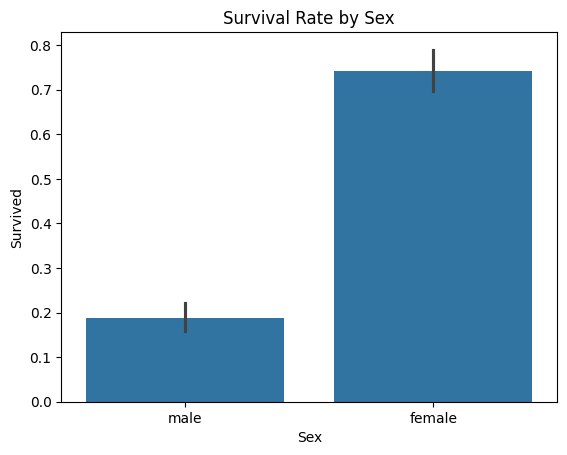

In [13]:
sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival Rate by Sex')
plt.show()

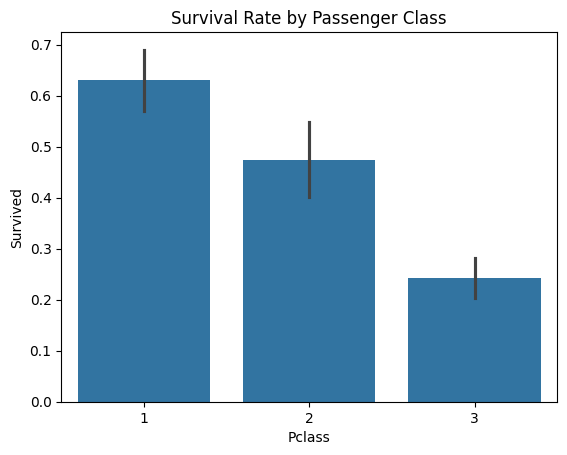

In [14]:
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival Rate by Passenger Class')
plt.show()

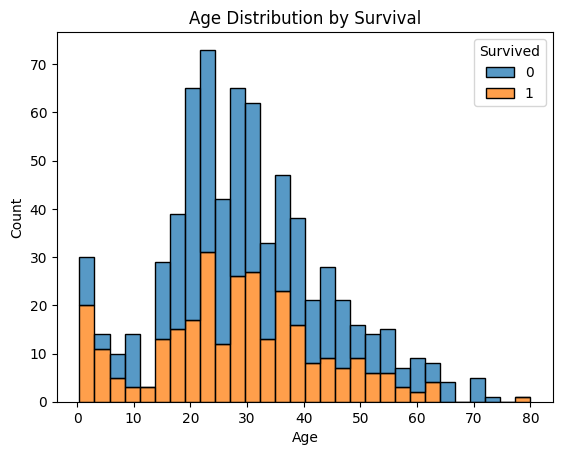

In [15]:
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()

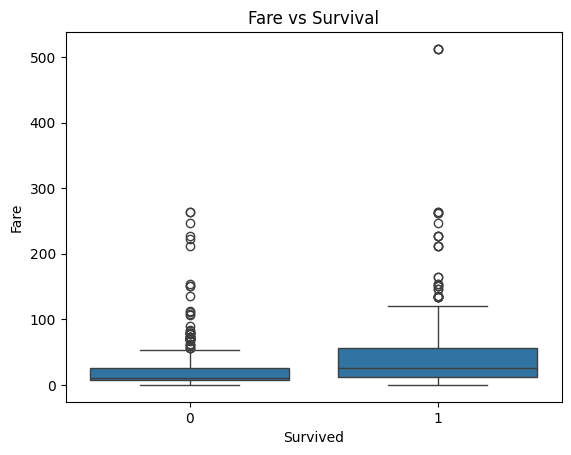

In [16]:
sns.boxplot(x='Survived', y='Fare', data=train)
plt.title('Fare vs Survival')
plt.show()

In [17]:
# Extract title from Name (Mr, Mrs, Miss, etc.) - helps fill Age smartly
for df in [train, test]:
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\s*\.')

train['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [18]:
for df in [train, test]:
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())  # fallback for any leftover gaps

train['Age'].isnull().sum()

np.int64(0)

In [19]:
for df in [train, test]:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df.drop('Cabin', axis=1, inplace=True)

train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64

In [20]:
for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,Mr,1


In [21]:
for df in [train, test]:
    df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr',
                                        'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    df['Title'] = df['Title'].map({'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4})
    df['Title'] = df['Title'].fillna(0)

train['Title'].value_counts()

Title
0.0    518
1.0    185
2.0    126
3.0     40
4.0     22
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = ['Pclass','Sex','Age','Fare','FamilySize','Embarked','Title']
X = train[features]
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
pred = log_reg.predict(X_val)
print("Logistic Regression accuracy:", accuracy_score(y_val, pred))

Logistic Regression accuracy: 0.7821229050279329


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree accuracy:", accuracy_score(y_val, dt.predict(X_val)))

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest accuracy:", accuracy_score(y_val, rf.predict(X_val)))

Decision Tree accuracy: 0.7988826815642458
Random Forest accuracy: 0.8435754189944135


In [24]:
test_preds = rf.predict(test[features])

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_preds
})
submission.to_csv('submission.csv', index=False)

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


In [25]:
train[train['Fare'] > 50].shape

(160, 13)

In [26]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Title', 'FamilySize'],
      dtype='object')

In [27]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Title', 'FamilySize'],
      dtype='object')

In [28]:
train.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [29]:
train[train['Pclass'] == 1].groupby('Sex')['Survived'].mean()


Sex
0    0.368852
1    0.968085
Name: Survived, dtype: float64

In [30]:
train.sort_values('Fare', ascending=False).head(10)  # top 10 highest fares

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",0,36.0,0,1,PC 17755,512.3292,1,0.0,2
258,259,1,1,"Ward, Miss. Anna",1,35.0,0,0,PC 17755,512.3292,1,1.0,1
737,738,1,1,"Lesurer, Mr. Gustave J",0,35.0,0,0,PC 17755,512.3292,1,0.0,1
88,89,1,1,"Fortune, Miss. Mabel Helen",1,23.0,3,2,19950,263.0000,0,1.0,6
438,439,0,1,"Fortune, Mr. Mark",0,64.0,1,4,19950,263.0000,0,0.0,6
341,342,1,1,"Fortune, Miss. Alice Elizabeth",1,24.0,3,2,19950,263.0000,0,1.0,6
27,28,0,1,"Fortune, Mr. Charles Alexander",0,19.0,3,2,19950,263.0000,0,0.0,6
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",1,21.0,2,2,PC 17608,262.3750,1,1.0,5
311,312,1,1,"Ryerson, Miss. Emily Borie",1,18.0,2,2,PC 17608,262.3750,1,1.0,5
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1,50.0,0,1,PC 17558,247.5208,1,2.0,2


In [31]:
train['Embarked'].value_counts(normalize=True)  # % of passengers per port

Embarked
0    0.725028
1    0.188552
2    0.086420
Name: proportion, dtype: float64

In [32]:
# 1. Who paid the top 5 highest fares? Show their name, class, and survival status
train.sort_values('Fare', ascending=False)[['Name','Pclass','Survived']].head(5)

# 2. What % of passengers embarked from each port?
train['Embarked'].value_counts(normalize=True)

# 3. Average fare paid, by class
train.groupby('Pclass')['Fare'].mean()

# 4. Youngest and oldest passenger who survived
train[train['Survived']==1]['Age'].min(), train[train['Survived']==1]['Age'].max()

# 5. How many passengers had Title == 'Master' (young boys) and what was their survival rate?
train[train['Title']==3].shape[0], train[train['Title']==3]['Survived'].mean()

(40, np.float64(0.575))

In [33]:
train.sort_values('Fare', ascending=False)[['Name','Pclass','Survived']].head(5)


,Name,Pclass,Survived
679,"Cardeza, Mr. Thomas Drake Martinez",1,1
258,"Ward, Miss. Anna",1,1
737,"Lesurer, Mr. Gustave J",1,1
88,"Fortune, Miss. Mabel Helen",1,1
438,"Fortune, Mr. Mark",1,0


In [34]:
train['Embarked'].value_counts(normalize=True)

Embarked
0    0.725028
1    0.188552
2    0.086420
Name: proportion, dtype: float64

In [35]:
train.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [36]:
train[train['Survived']==1]['Age'].min(), train[train['Survived']==1]['Age'].max()

(0.42, 80.0)